1. Load the given dataset and identify missing values in numerical columns, then replace them using mean imputation and display the dataset before and after preprocessing.

In [2]:
import pandas as pd
import numpy as np

# load dataset
df=pd.read_csv('Titanic-Dataset.csv')
print("Dataset before preprocessing:")
print(df.head())

#identify numerical columns
num_cols=df.select_dtypes(include=np.number).columns

# check missing values in numerical columns
print("\nMissing values in numerical columns:")
print(df[num_cols].isnull().sum())

# fill missing values with mean
df[num_cols]=df[num_cols].fillna(df[num_cols].mean())



Dataset before preprocessing:
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]

Missing values in numerical columns:
PassengerId      0
Survived         0
Pclass           0
Age            177
SibSp            0
Parch            0
Fare             0
dtype: int64


In [3]:
# display dataset after preprocessing
print("\nDataset after preprocessing:")
print(df.head())

# verify missing values are handled
print("\n Missing values after imputation:")
print(df[num_cols].isnull().sum())


Dataset after preprocessing:
   PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0            1         0       3  ...   7.2500   NaN         S
1            2         1       1  ...  71.2833   C85         C
2            3         1       3  ...   7.9250   NaN         S
3            4         1       1  ...  53.1000  C123         S
4            5         0       3  ...   8.0500   NaN         S

[5 rows x 12 columns]

 Missing values after imputation:
PassengerId    0
Survived       0
Pclass         0
Age            0
SibSp          0
Parch          0
Fare           0
dtype: int64


In [4]:
# identify categorical columns
cat_cols=df.select_dtypes(include='object').columns

# check missing values in cat_cols
print("\nMissing values in categorical columns:")
print(df[cat_cols].isnull().sum())

# frequency before filling missing values
print("\n Frequency before preprocessing:")
for col in cat_cols:
    print(f"\n Column: {col}")
    print(df[col].value_counts(dropna=False))

# fill missing values with mode
for col in cat_cols:
    if df[col].isnull().all():
        print(f"Skipping {col} (all values missing)")
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# Step 6: Frequency AFTER filling
print("\nFrequency AFTER preprocessing:\n")
for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())




Missing values in categorical columns:
Name          0
Sex           0
Ticket        0
Cabin       687
Embarked      2
dtype: int64

 Frequency before preprocessing:

 Column: Name
Name
Dooley, Mr. Patrick                                    1
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
                                                      ..
Hewlett, Mrs. (Mary D Kingcome)                        1
Vestrom, Miss. Hulda Amanda Adolfina                   1
Andersson, Mr. Anders Johan                            1
Saundercock, Mr. William Henry                         1
Bonnell, Miss. Elizabeth                               1
Name: count, Length: 891, dtype: int64

 Column: Sex
Sex
male      577
female    314
Name: count, dtype: int64

 Column: Ticket
Ticket
347082              7
1601                7
CA. 234

3. Using the given dataset, apply Label Encoding on a categorical column and display the transformed values.

In [5]:
from sklearn.preprocessing import LabelEncoder

# check column
print("original values:\n")
print(df['Sex'].head())

# apply label encoding
le=LabelEncoder()
df['Sex_encoded']=le.fit_transform(df['Sex'])

# display transformed values
print("\n Encoded values:\n")
print(df[['Sex','Sex_encoded']].head())


original values:

0      male
1    female
2    female
3    female
4      male
Name: Sex, dtype: object

 Encoded values:

      Sex  Sex_encoded
0    male            1
1  female            0
2  female            0
3  female            0
4    male            1


4. Using the given dataset, apply One-Hot Encoding on categorical features and show the increase in number of columns.

In [6]:
# identify categorical columns
cat_cols=df.select_dtypes(include='object').columns

# check original shape
print("Original shape:",df.shape)

# apply one-hot encoding
df_encoded=pd.get_dummies(df,columns=cat_cols,drop_first=True)

# display new shape
print("New shape after one-hot encoding:",df_encoded.shape)

# display first few rows of the new dataset
print("\nDataset after one-hot encoding:")
print(df_encoded.head())

Original shape: (891, 13)
New shape after one-hot encoding: (891, 1727)

Dataset after one-hot encoding:
   PassengerId  Survived  Pclass  ...  Cabin_T  Embarked_Q  Embarked_S
0            1         0       3  ...    False       False        True
1            2         1       1  ...    False       False       False
2            3         1       3  ...    False       False        True
3            4         1       1  ...    False       False        True
4            5         0       3  ...    False       False        True

[5 rows x 1727 columns]


5. Using the given dataset, perform Min-Max scaling on numerical features and verify that all values lie between 0 and 1.

In [7]:
# select numerical columns
from sklearn.preprocessing import MinMaxScaler
num_cols=df.select_dtypes(include=['int64','float64']).columns

# apply min max scaling
scaler=MinMaxScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])

# display dataset after scaling
print("\nDataset after Min-Max Scaling:")
print(df.head())

# verify range
print("\n Minimum values :\n",df[num_cols].min())
print("\n Maximum values :\n",df[num_cols].max())


Dataset after Min-Max Scaling:
   PassengerId  Survived  Pclass  ...    Cabin Embarked  Sex_encoded
0     0.000000       0.0     1.0  ...  B96 B98        S          1.0
1     0.001124       1.0     0.0  ...      C85        C          0.0
2     0.002247       1.0     1.0  ...  B96 B98        S          0.0
3     0.003371       1.0     0.0  ...     C123        S          0.0
4     0.004494       0.0     1.0  ...  B96 B98        S          1.0

[5 rows x 13 columns]

 Minimum values :
 PassengerId    0.0
Survived       0.0
Pclass         0.0
Age            0.0
SibSp          0.0
Parch          0.0
Fare           0.0
Sex_encoded    0.0
dtype: float64

 Maximum values :
 PassengerId    1.0
Survived       1.0
Pclass         1.0
Age            1.0
SibSp          1.0
Parch          1.0
Fare           1.0
Sex_encoded    1.0
dtype: float64


6. Using the given dataset, apply StandardScaler and verify mean is approximately 0 and standard deviation is 1.

In [8]:
from sklearn.preprocessing import StandardScaler

# select numerical columns
num_cols=df.select_dtypes(include=['int64','float64']).columns

# apply StandardScaler
scaler=StandardScaler()
df[num_cols]=scaler.fit_transform(df[num_cols])

# display dataset after scaling
print("\nDataset after Standard Scaling:")
print(df.head())


Dataset after Standard Scaling:
   PassengerId  Survived    Pclass  ...    Cabin Embarked  Sex_encoded
0    -1.730108 -0.789272  0.827377  ...  B96 B98        S     0.737695
1    -1.726220  1.266990 -1.566107  ...      C85        C    -1.355574
2    -1.722332  1.266990  0.827377  ...  B96 B98        S    -1.355574
3    -1.718444  1.266990 -1.566107  ...     C123        S    -1.355574
4    -1.714556 -0.789272  0.827377  ...  B96 B98        S     0.737695

[5 rows x 13 columns]


In [9]:
# verify mean and std
print("\n Mean after scaling:\n",df[num_cols].mean())
print("\n Std after scaling:\n",df[num_cols].std())


 Mean after scaling:
 PassengerId    6.379733e-17
Survived       3.987333e-17
Pclass        -8.772133e-17
Age           -7.974666e-17
SibSp          4.386066e-17
Parch          7.376566e-17
Fare           1.196200e-17
Sex_encoded   -1.156327e-16
dtype: float64

 Std after scaling:
 PassengerId    1.000562
Survived       1.000562
Pclass         1.000562
Age            1.000562
SibSp          1.000562
Parch          1.000562
Fare           1.000562
Sex_encoded    1.000562
dtype: float64


7. Using the given dataset, create a new feature using existing columns and display the updated dataset.

In [12]:
# instead of SibSp(siblings/spouse) and Parch(parents/children), we can create a new feature called 
# 'FamilySize'= SibSp + Parch + 1 (including the passenger themselves)

df=pd.read_csv('Titanic-Dataset.csv')
# create new feature 'FamilySize'
df["FamilySize"]=df['SibSp']+df['Parch']+1

# display updated dataset
print("\nDataset after creating 'FamilySize' feature:")
print(df[['SibSp','Parch','FamilySize']].head())


Dataset after creating 'FamilySize' feature:
   SibSp  Parch  FamilySize
0      1      0           2
1      1      0           2
2      0      0           1
3      1      0           2
4      0      0           1


8. Using the given dataset, display summary statistics including mean, median, minimum, maximum, and standard deviation.

In [20]:
# summary statistics
df=pd.read_csv('Titanic-Dataset.csv')
pd.set_option('display.max_columns', None)
print("\nSummary statistics")
print(df.describe(include='all'))

print("Median:",df.median(numeric_only=True))


Summary statistics
        PassengerId    Survived      Pclass                 Name   Sex  \
count    891.000000  891.000000  891.000000                  891   891   
unique          NaN         NaN         NaN                  891     2   
top             NaN         NaN         NaN  Dooley, Mr. Patrick  male   
freq            NaN         NaN         NaN                    1   577   
mean     446.000000    0.383838    2.308642                  NaN   NaN   
std      257.353842    0.486592    0.836071                  NaN   NaN   
min        1.000000    0.000000    1.000000                  NaN   NaN   
25%      223.500000    0.000000    2.000000                  NaN   NaN   
50%      446.000000    0.000000    3.000000                  NaN   NaN   
75%      668.500000    1.000000    3.000000                  NaN   NaN   
max      891.000000    1.000000    3.000000                  NaN   NaN   

               Age       SibSp       Parch  Ticket        Fare Cabin Embarked  
count   714

9. Using the given dataset, plot histograms for numerical features and describe the distribution.

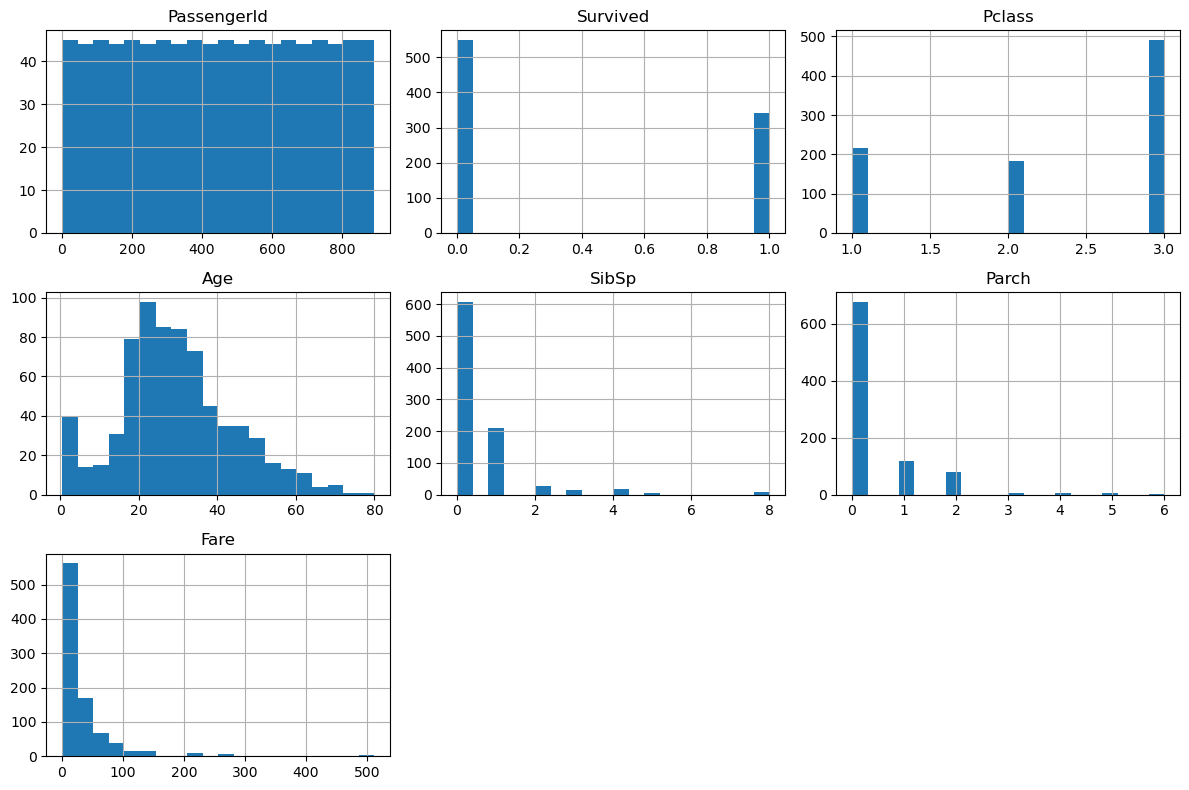

In [21]:
import matplotlib.pyplot as plt

# dataset
df=pd.read_csv('Titanic-Dataset.csv')
# select numerical columns
num_cols=df.select_dtypes(include=['int64','float64']).columns

# plot histograms
df[num_cols].hist(figsize=(12,8),bins=20)

plt.tight_layout()
plt.show()

10. Using the given dataset, draw boxplots for selected features and identify outliers.

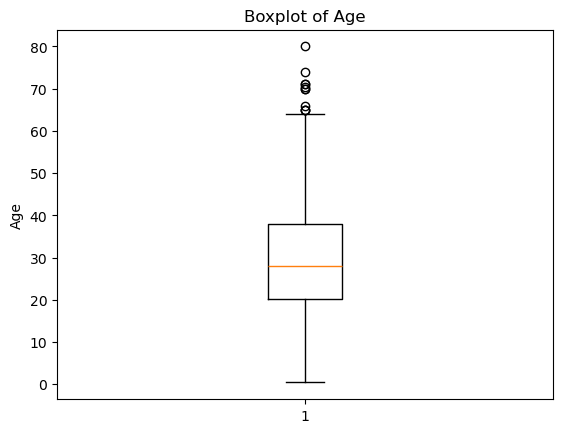

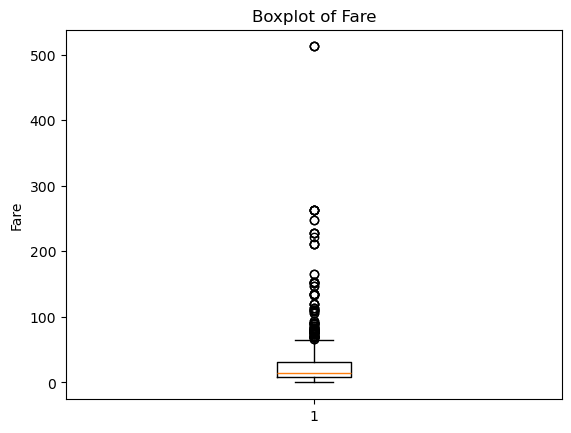

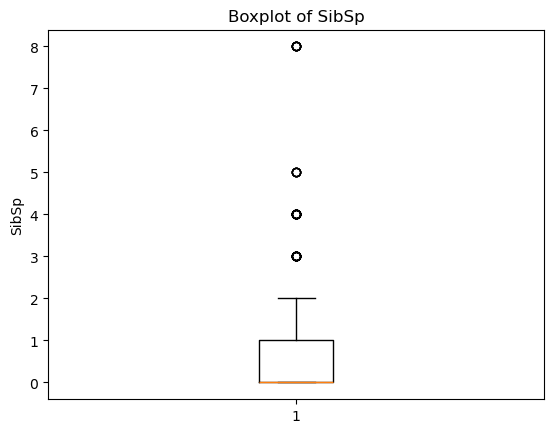

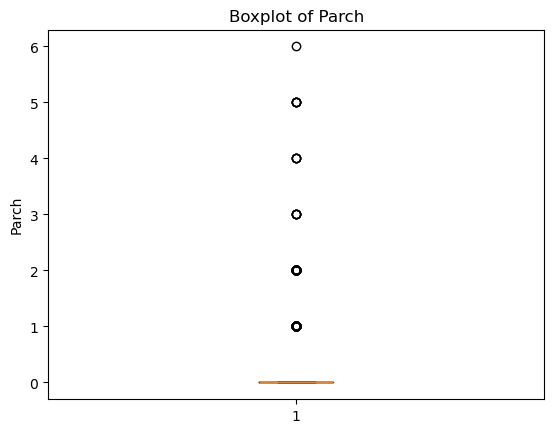

In [22]:
# select important numerical columns
cols=['Age','Fare','SibSp','Parch']

# plot boxplots
for col in cols:
    plt.figure()
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

11. Using the given dataset, compute the correlation matrix and identify highly correlated features.

In [23]:
# select numerical columns
num_df=df.select_dtypes(include=['int64','float64'])

# compute correlation matrix
corr_matrix=num_df.corr()

# display correlation matrix
print("\nCorrelation Matrix:")
print(corr_matrix)



Correlation Matrix:
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


In [ ]:
# find strong correlations (>0.5)
print("\n Highly correlated features:\n")

for col in corr_matrix.columns:
    for row in corr_matrix.index:
        if col!=row and abs(corr_matrix.loc[row,col])>0.5:
            print(f"{row} and {col} -> {corr_matrix.loc[row,col]:.2f}")


 Highly correlated features:

Fare and Pclass -> -0.55
Pclass and Fare -> -0.55


12. Using the given dataset, plot a heatmap for correlation matrix and interpret relationships.

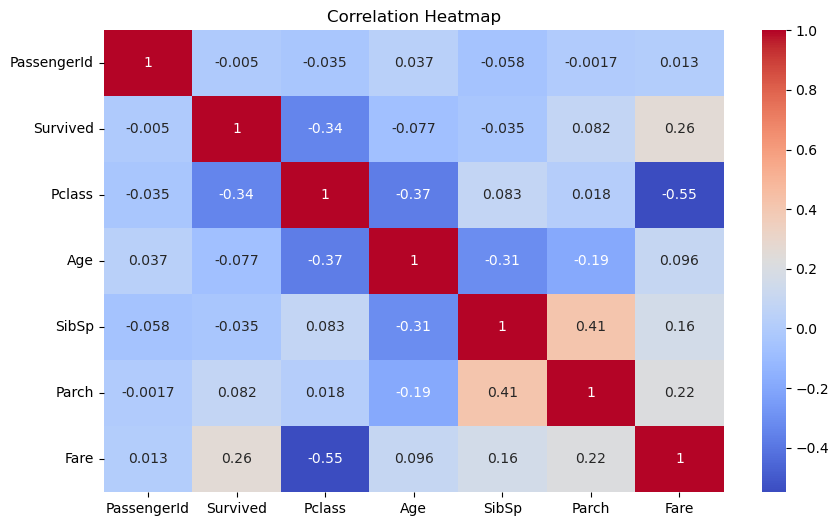

In [27]:
import seaborn as sns

# select numerical columns
num_df=df.select_dtypes(include=['int64','float64'])

# compute correlation matrix
corr_matrix=num_df.corr()

# plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

13. Using the given dataset, generate a pairplot and analyze relationships between variables.

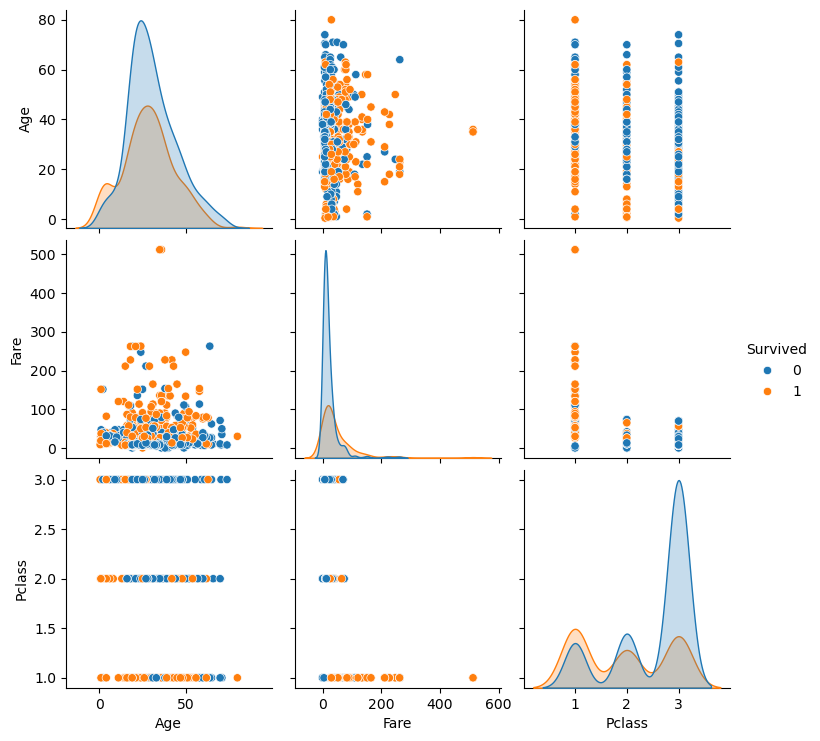

In [28]:
# select important columns (keeping it small for clarity)
cols=['Survived','Age','Fare','Pclass']

# plot pairplot
sns.pairplot(df[cols],hue='Survived')

plt.show()

14. Using the given dataset, calculate skewness of features and identify skewed variables.

In [29]:
# select numerical columns
num_cols=df.select_dtypes(include=['int64','float64']).columns

# calculate skewness
skew_values=df[num_cols].skew()

print("Skewness of features:\n")
print(skew_values)

Skewness of features:

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Age            0.389108
SibSp          3.695352
Parch          2.749117
Fare           4.787317
dtype: float64


In [30]:
# classify skewness
for col in skew_values.index:
    if skew_values[col]>0.5:
        print(f"{col} is right skewed")
    elif skew_values[col]<-0.5:
        print(f"{col} is left skewed")
    else:
        print(f"{col} is approximately normal")

PassengerId is approximately normal
Survived is approximately normal
Pclass is left skewed
Age is approximately normal
SibSp is right skewed
Parch is right skewed
Fare is right skewed


15. Using the given dataset, implement a Logistic Regression model for binary classification.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df=pd.read_csv('Titanic-Dataset.csv')
# convert categorical column "Sex" using label encoding
df['Sex']=df['Sex'].map({'male':0,'female':1})

# drop unnecessary columns for modeling
df=df.drop(['Name','Ticket','Cabin'],axis=1)

# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

# fill missing values
df=df.fillna(df.mean(numeric_only=True))

# define features(x) and target(y)
x=df.drop('Survived',axis=1)
y=df['Survived']  

# train logistic regression model
model=LogisticRegression(max_iter=1000)
model.fit(x,y)

print("Model trained successfully!")

Model trained successfully!


16. Using the given dataset, split the data into training and testing sets in 75:25 ratio.